#### Classification için breast_cancer verileri

In [77]:
import random
import platform
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

warnings.filterwarnings("ignore")

SEED=42
random.seed(SEED)
np.random.seed(SEED)

sns.set_theme(style="whitegrid",context ="notebook")
plt.rcParams["figure.figsize"]=(7,4)
plt.rcParams["figure.dpi"] = 110


print(f"python: {sys.version.split()[0]}")
print(f"Platform:{platform.platform()}")
print(f"seaborn: {sns.__version__}")
print(f"pandas: {pd.__version__}")
print(f"numpy: {np.__version__}")
print(f"sklearn: {sklearn.__version__}")

python: 3.10.11
Platform:Windows-10-10.0.26200-SP0
seaborn: 0.13.2
pandas: 2.3.3
numpy: 2.2.6
sklearn: 1.7.2


In [78]:
bc = load_breast_cancer(as_frame=True)
X_clf, y_clf = bc.data, bc.target
X_clf.head(2)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902


In [79]:
print("Sınıf dağılımı(0=habis, 1= iyi huylu):")
print(y_clf.value_counts().rename({0:"habis",1:"iyi"}))
X_clf.iloc[:,:6].describe().T.round(2)

Sınıf dağılımı(0=habis, 1= iyi huylu):
target
iyi      357
habis    212
Name: count, dtype: int64


,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.13,3.52,6.98,11.70,13.37,15.78,28.11
mean texture,569.0,19.29,4.30,9.71,16.17,18.84,21.80,39.28
mean perimeter,569.0,91.97,24.30,43.79,75.17,86.24,104.10,188.50
mean area,569.0,654.89,351.91,143.50,420.30,551.10,782.70,2501.00
mean smoothness,569.0,0.10,0.01,0.05,0.09,0.10,0.11,0.16
mean compactness,569.0,0.10,0.05,0.02,0.06,0.09,0.13,0.35


In [80]:
Xc_train,Xc_test,yc_train,yc_test=train_test_split(X_clf,y_clf,test_size=0.2,random_state=SEED)

#### Modellere train test sokuyoz

In [81]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score

siniflandiricilar = {
    "Baseline": DummyClassifier(strategy="most_frequent").fit(Xc_train,yc_train),
    "Logistic": LogisticRegression().fit(Xc_train,yc_train),
    "KNN": KNeighborsClassifier().fit(Xc_train,yc_train),
    "Karar ağacı": DecisionTreeClassifier().fit(Xc_train,yc_train),
    "Rastgele orman": RandomForestClassifier().fit(Xc_train,yc_train)
}


satirlar =[]

for ad,m in siniflandiricilar.items():
  m.fit(Xc_train,yc_train)
  satirlar.append(
      {
          "Model": ad,
          "Eğitim" : accuracy_score(yc_train,m.predict(Xc_train)),
          "Test": accuracy_score(yc_test,m.predict(Xc_test))
      }
  )

pd.DataFrame(satirlar).set_index("Model").round(3)

,Eğitim,Test
Model,,
Baseline,0.629,0.623
Logistic,0.949,0.947
KNN,0.941,0.956
Karar ağacı,1.000,0.947
Rastgele orman,1.000,0.965


#### Confusion matrix

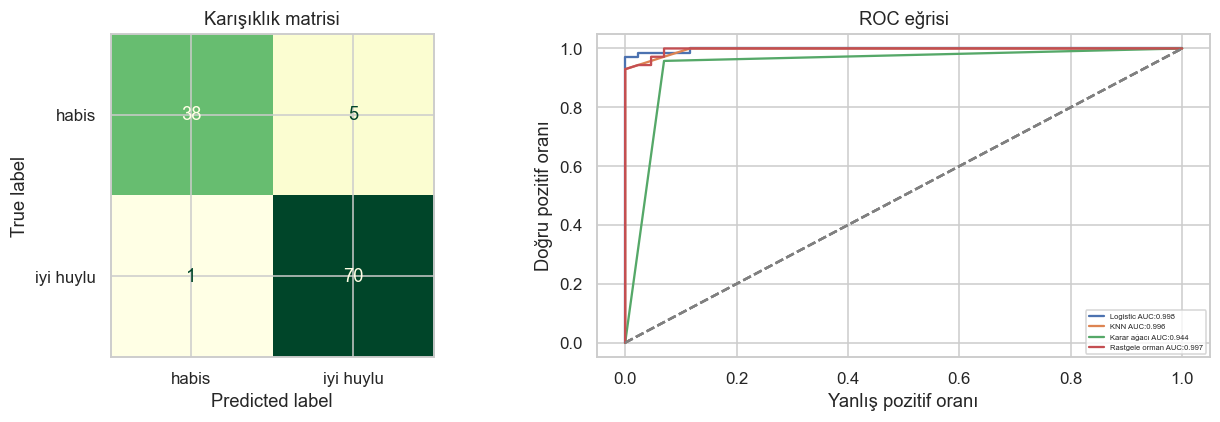

In [82]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay ,classification_report, roc_curve, roc_auc_score

model = siniflandiricilar["Logistic"]
tahmin = model.predict(Xc_test)
olasilik = model.predict_proba(Xc_test)[:,1]

fig ,axes = plt.subplots(1,2,figsize=(12,4))

cm = confusion_matrix(yc_test,tahmin)
ConfusionMatrixDisplay.from_predictions(yc_test,tahmin, display_labels =["habis","iyi huylu"], cmap="YlGn",ax=axes[0],colorbar=False)
axes[0].set_title("Karışıklık matrisi")
axes


for ad in ["Logistic","KNN","Karar ağacı","Rastgele orman"]:
  p=siniflandiricilar[ad].predict_proba(Xc_test)[:,1]
  fpr,tpr,_=roc_curve(yc_test,p)
  axes[1].plot(fpr,tpr,label=f"{ad} AUC:{roc_auc_score(yc_test,p):.3f}")
  axes[1].plot([0,1],[0,1],linestyle="--",color="gray")
  axes[1].set_xlabel("Yanlış pozitif oranı")
  axes[1].set_ylabel("Doğru pozitif oranı")
  axes[1].set_title("ROC eğrisi")
  axes[1].legend(fontsize=5)
  axes[1].grid(True)

plt.tight_layout()
plt.show()

#### Cross validation (Çapraz doğrulama)

In [83]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

In [84]:
cv = StratifiedKFold(n_splits=5, shuffle =True, random_state=SEED)

satirlar =[]

for ad, m in siniflandiricilar.items():
  skorlar=cross_val_score(m,Xc_train,yc_train,cv=cv,scoring="accuracy")
  satirlar.append({"Model":ad,"Ortalama skor":skorlar.mean(),"Standart sapma":skorlar.std()})

cv_sonuc= pd.DataFrame(satirlar).set_index("Model").sort_values("Ortalama skor",ascending=False).round(3)
display(cv_sonuc)

,Ortalama skor,Standart sapma
Model,,
Rastgele orman,0.967,0.020
Logistic,0.945,0.021
KNN,0.921,0.038
Karar ağacı,0.921,0.041
Baseline,0.629,0.004


In [85]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge,Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
pipe = make_pipeline(StandardScaler(),KNeighborsClassifier())

param_grid = {
    "kneighborsclassifier__n_neighbors":[1,3,5,7,9,11,15,21],
    "kneighborsclassifier__weights":["uniform","distance"]
}

opt =GridSearchCV(pipe,param_grid,cv=cv,scoring="accuracy")
opt.fit(Xc_train,yc_train)

print("best parametre:", opt.best_params_)
print(f"en iyi cv:{opt.best_score_:3f}")


best parametre: {'kneighborsclassifier__n_neighbors': 7, 'kneighborsclassifier__weights': 'uniform'}
en iyi cv:0.967033


#### Eğitimi, veri setini yanlış bölerek yaparsak ne olur?

In [86]:
scaler_yanlis= StandardScaler().fit(X_clf)
Xc_tr= scaler_yanlis.transform(Xc_train)
Xc_te= scaler_yanlis.transform(Xc_test)

In [87]:
scaler_dogru = StandardScaler().fit(Xc_train)
Xc_tr= scaler_dogru.transform(Xc_train)
Xc_te= scaler_dogru.transform(Xc_test)

In [88]:
print("yanlış yöntem " ,scaler_yanlis.mean_[:3].round(2))
print("doğru yöntem" ,scaler_dogru.mean_[:3].round(2))

yanlış yöntem  [14.13 19.29 91.97]
doğru yöntem [14.12 19.19 91.88]


#### Overfit ve underfit'e değinelim

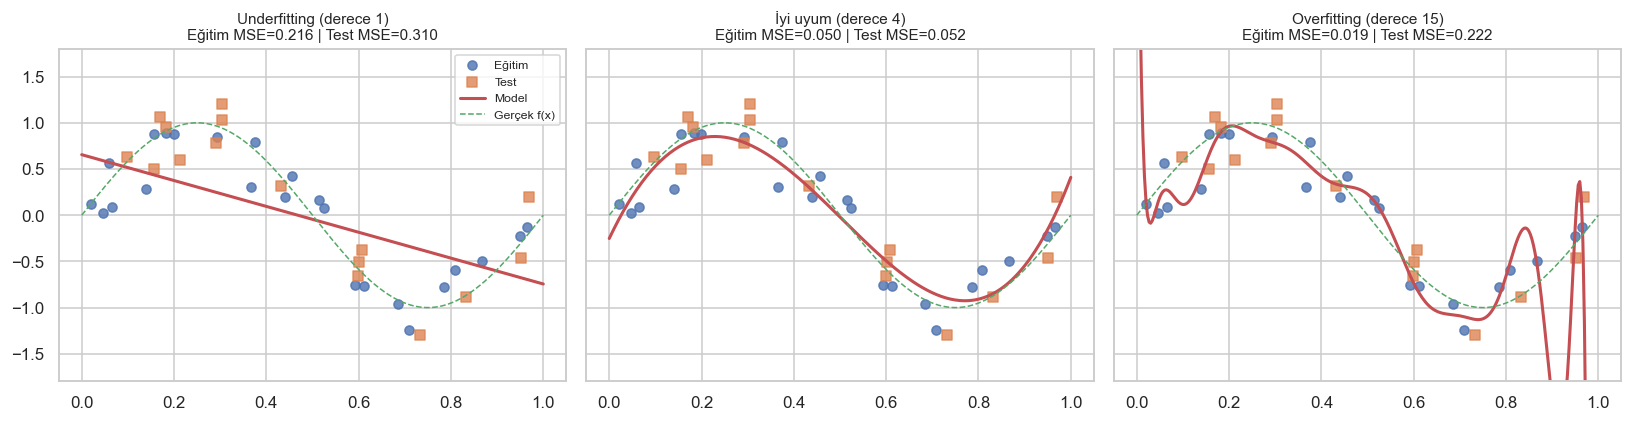

In [90]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

rng = np.random.RandomState(SEED)
n = 40
x = np.sort(rng.uniform(0, 1, n))
y = np.sin(2 * np.pi * x) + rng.normal(0, 0.25, n)  # gerçek fonksiyon + gürültü

x_tr, x_te, y_tr, y_te = train_test_split(x.reshape(-1, 1), y, test_size=0.4, random_state=SEED)

xs = np.linspace(0, 1, 300).reshape(-1, 1)
dereceler = [1, 4, 15]
basliklar = ["Underfitting (derece 1)", "İyi uyum (derece 4)", "Overfitting (derece 15)"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, d, b in zip(axes, dereceler, basliklar):
    model = make_pipeline(PolynomialFeatures(d), StandardScaler(), LinearRegression())
    model.fit(x_tr, y_tr)
    tr_hata = mean_squared_error(y_tr, model.predict(x_tr))
    te_hata = mean_squared_error(y_te, model.predict(x_te))
    ax.scatter(x_tr, y_tr, label="Eğitim", alpha=0.8)
    ax.scatter(x_te, y_te, label="Test", alpha=0.8, marker="s")
    ax.plot(xs, model.predict(xs), "r-", lw=2, label="Model")
    ax.plot(xs, np.sin(2 * np.pi * xs), "g--", lw=1, label="Gerçek f(x)")
    ax.set_ylim(-1.8, 1.8)
    ax.set_title(f"{b}\nEğitim MSE={tr_hata:.3f} | Test MSE={te_hata:.3f}", fontsize=10)
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

#### Model karmaşıklığı arttıkça eğitim ve test hatası nasıl değişir?


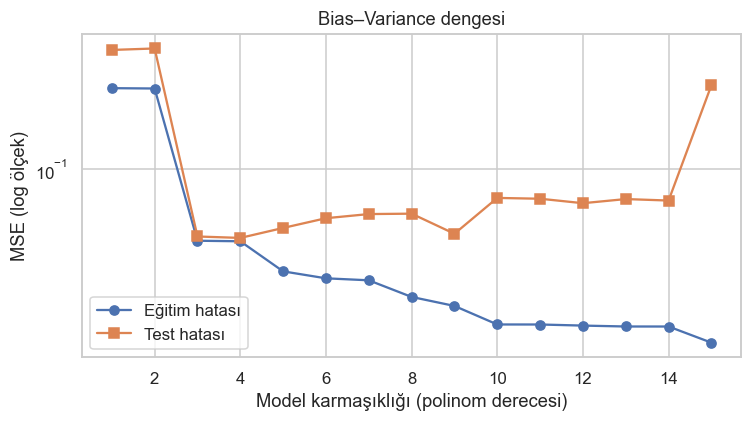

Test hatasının en düşük olduğu derece: 4


In [91]:
# Model karmaşıklığı arttıkça eğitim ve test hatası nasıl değişir?
derece_araligi = range(1, 16)
egitim_hatalari, test_hatalari = [], []

for d in derece_araligi:
    model = make_pipeline(PolynomialFeatures(d), StandardScaler(), LinearRegression())
    model.fit(x_tr, y_tr)
    egitim_hatalari.append(mean_squared_error(y_tr, model.predict(x_tr)))
    test_hatalari.append(mean_squared_error(y_te, model.predict(x_te)))

plt.figure(figsize=(7, 4))
plt.plot(derece_araligi, egitim_hatalari, "o-", label="Eğitim hatası")
plt.plot(derece_araligi, test_hatalari, "s-", label="Test hatası")
plt.yscale("log")
plt.xlabel("Model karmaşıklığı (polinom derecesi)")
plt.ylabel("MSE (log ölçek)")
plt.title("Bias–Variance dengesi")
plt.legend()
plt.tight_layout()
plt.show()

en_iyi = list(derece_araligi)[int(np.argmin(test_hatalari))]
print(f"Test hatasının en düşük olduğu derece: {en_iyi}")